# News-to-Signal Case Study

## Research Question
Can simple text-derived features from financial news be transformed into
a cross-sectional ranking signal with measurable predictive behavior?

## Project Goal
This notebook demonstrates a reproducible quant research workflow:
from raw news text → structured features → signal construction → evaluation.
The goal is research process clarity, not production-ready performance.

In [1]:
# Setup: add parent directory to path for imports
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import project modules
from src import preprocess, feature_engineering, signal_construction, evaluation
from config import FIGURES_DIR, TABLES_DIR

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports successful!")

Imports successful!


## Section 2 — Data Assembly and Preprocessing

This section fetches financial news from Yahoo Finance RSS and price data
from yfinance. It computes forward returns and performs data quality checks.

**Pipeline steps:**
1. Fetch news headlines for all tickers in the universe
2. Fetch daily close prices with retry and cache logic
3. Compute future_return_5d for each headline
4. Aggregate headlines by ticker-date
5. Run data quality assertions

In [2]:
# Run the preprocessing pipeline
# Note: This may take a few minutes as it fetches data from external APIs
df_raw = preprocess.main()
print(f"\nFinal dataset shape: {df_raw.shape}")

News Preprocessing Pipeline

[1/5] Fetching news headlines...
Fetching news for AAPL...
Fetching news for MSFT...
Fetching news for GOOGL...
Fetching news for AMZN...
Fetching news for NVDA...
Fetching news for META...
Fetching news for TSLA...
Fetching news for JPM...
Fetching news for JNJ...
Fetching news for V...
Fetching news for UNH...
Fetching news for XOM...
Fetching news for WMT...
Fetching news for MA...
Fetching news for PG...
Fetching news for HD...
Fetching news for CVX...
Fetching news for MRK...
Fetching news for ABBV...
Fetching news for PEP...
Fetching news for KO...
Fetching news for BAC...
Fetching news for PFE...
Fetching news for AVGO...
Fetching news for COST...
Fetching news for TMO...
Fetching news for DIS...
Fetching news for CSCO...
Fetching news for ADBE...
Fetching news for NKE...
Fetching news for ABT...
Fetching news for MCD...
Fetching news for CRM...
Fetching news for ACN...
Fetching news for WFC...
Fetching news for TXN...
Fetching news for VZ...
Fetchin

In [3]:
# Display first few rows
df_raw.head()

,date,ticker,headline,headline_count,source,future_return_5d
7,2026-03-05,ABT,Balloon Catheter Market Competitive Landscape ...,2,Yahoo Finance,-0.013046
8,2026-03-06,ABT,Hologic's Diagnostics Strength in Focus: Is Mo...,3,Yahoo Finance,-0.041877
9,2026-03-09,ABT,2 Profitable Stocks on Our Watchlist and 1 We ...,2,Yahoo Finance,-0.005442
59,2026-03-09,HD,3 Things to Know About Home Depot Stock Before...,3,Yahoo Finance,-0.034987
67,2026-03-06,HON,Space Electronics Research Report 2026-2035: A...,4,Yahoo Finance,-0.013091


In [4]:
# Summary statistics
df_raw.describe()

,date,headline_count,future_return_5d
count,44,44.000000,44.000000
mean,2026-03-05 21:49:05.454545,2.181818,-0.024237
min,2026-03-02 00:00:00,1.000000,-0.092682
25%,2026-03-04 18:00:00,1.000000,-0.040611
50%,2026-03-06 00:00:00,2.000000,-0.025679
75%,2026-03-08 00:00:00,3.000000,-0.009505
max,2026-03-09 00:00:00,5.000000,0.013886
std,NaN,1.244013,0.025503


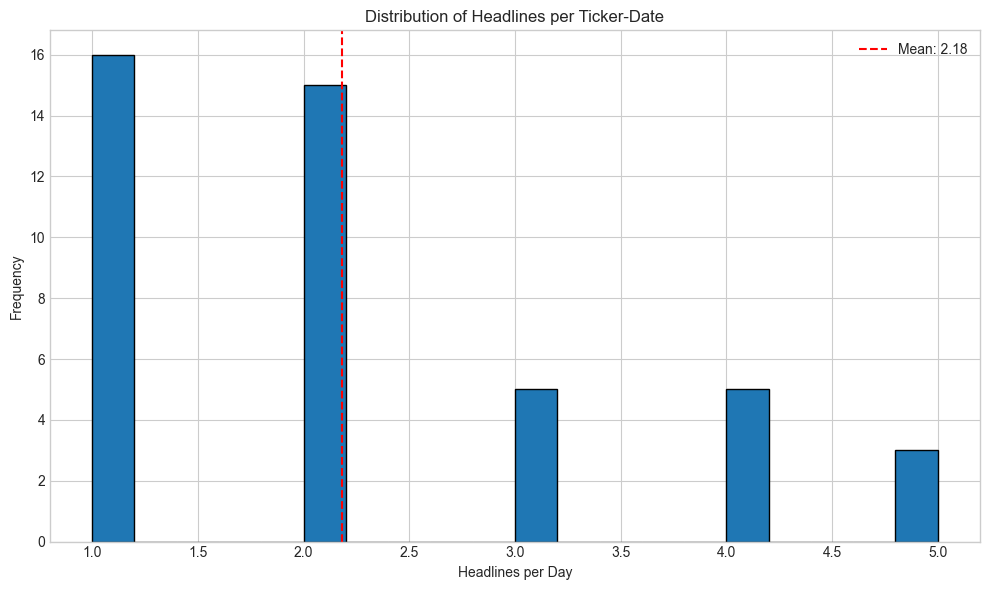

In [5]:
# Plot headline count distribution
fig, ax = plt.subplots(figsize=(10, 6))
df_raw['headline_count'].hist(bins=20, edgecolor='black', ax=ax)
ax.set_xlabel('Headlines per Day')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Headlines per Ticker-Date')
ax.axvline(df_raw['headline_count'].mean(), color='red', linestyle='--',
           label=f"Mean: {df_raw['headline_count'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/headline_count_distribution.png', dpi=150)
plt.show()

## Section 3 — Feature Engineering

This section transforms raw news text into structured features using the
Loughran-McDonald (LMD) Master Dictionary.

**Features computed:**
- **sentiment_score**: (positive_count - negative_count) / total_words, clipped to [-1, 1]
- **uncertainty_score**: uncertainty_count / total_words
- **event_intensity**: fraction of event keywords present in headline

In [6]:
# Apply feature engineering
df_features = feature_engineering.main(df_raw)
print(f"\nFeatures added. New shape: {df_features.shape}")

Loading Loughran-McDonald dictionary...
Loaded 347 positive, 2345 negative, 297 uncertainty words
Computing sentiment scores...
Computing uncertainty scores...
Computing event intensity...
Adding AI label placeholder...
Feature engineering complete. Shape: (44, 10)
Columns: ['date', 'ticker', 'headline', 'headline_count', 'source', 'future_return_5d', 'sentiment_score', 'uncertainty_score', 'event_intensity', 'ai_label']

Features added. New shape: (44, 10)


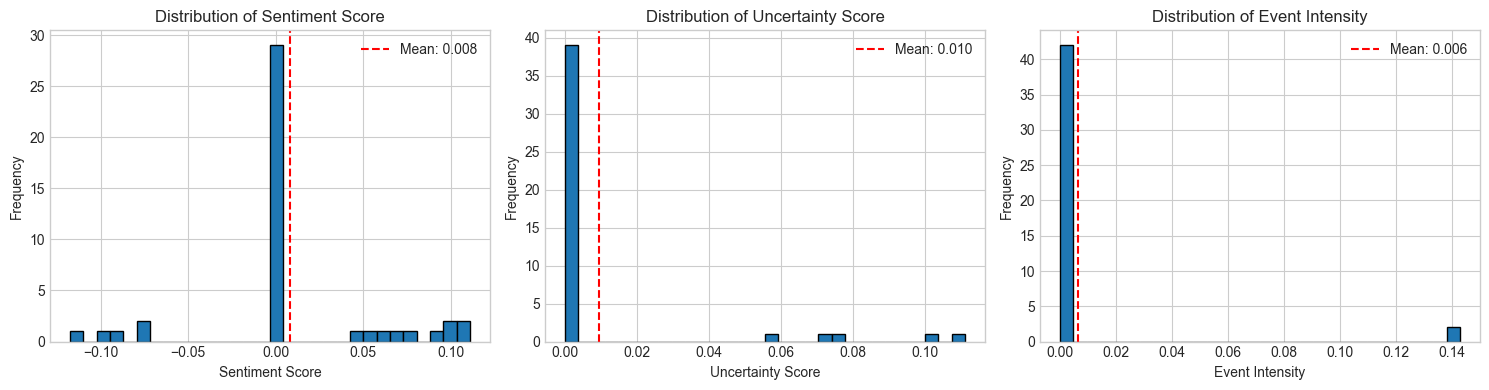

In [7]:
# Plot histograms for the three features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['sentiment_score', 'uncertainty_score', 'event_intensity']
titles = ['Sentiment Score', 'Uncertainty Score', 'Event Intensity']

for ax, feature, title in zip(axes, features, titles):
    df_features[feature].hist(bins=30, edgecolor='black', ax=ax)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {title}')
    ax.axvline(df_features[feature].mean(), color='red', linestyle='--',
               label=f"Mean: {df_features[feature].mean():.3f}")
    ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/feature_distributions.png', dpi=150)
plt.show()

## Section 4 — Signal Construction

This section applies cross-sectional z-score standardization and constructs
three distinct signals.

**Signals:**
- **signal_sentiment_only** = z(sentiment_score)
- **signal_sentiment_minus_uncertainty** = z(sentiment_score) - z(uncertainty_score)
- **signal_full** = z(sentiment_score) - z(uncertainty_score) + z(event_intensity)

All z-scores are computed independently within each trading date (cross-sectional).

In [8]:
# Apply signal construction
df_signals = signal_construction.main(df_features)
print(f"\nSignals constructed. Final shape: {df_signals.shape}")

Constructing signals...
Saved processed data to /Users/yizuo/news-to-signal/news-to-signal-case-study/data/processed/news_features.csv

Signal construction complete. Shape: (44, 13)
Signal columns: ['signal_sentiment_only', 'signal_sentiment_minus_uncertainty', 'signal_full']

Signal Summary Statistics:
       signal_sentiment_only  signal_sentiment_minus_uncertainty   signal_full
count           4.400000e+01                           44.000000  4.400000e+01
mean           -4.415660e-18                            0.000000 -1.135455e-17
std             8.352691e-01                            1.079697  8.764395e-01
min            -1.535896e+00                           -3.901410 -1.658393e+00
25%            -5.193376e-01                           -0.519338 -5.000000e-01
50%             2.242403e-03                            0.443524  1.101911e-01
75%             5.000000e-01                            0.500000  5.000000e-01
max             2.052875e+00                            2.38620

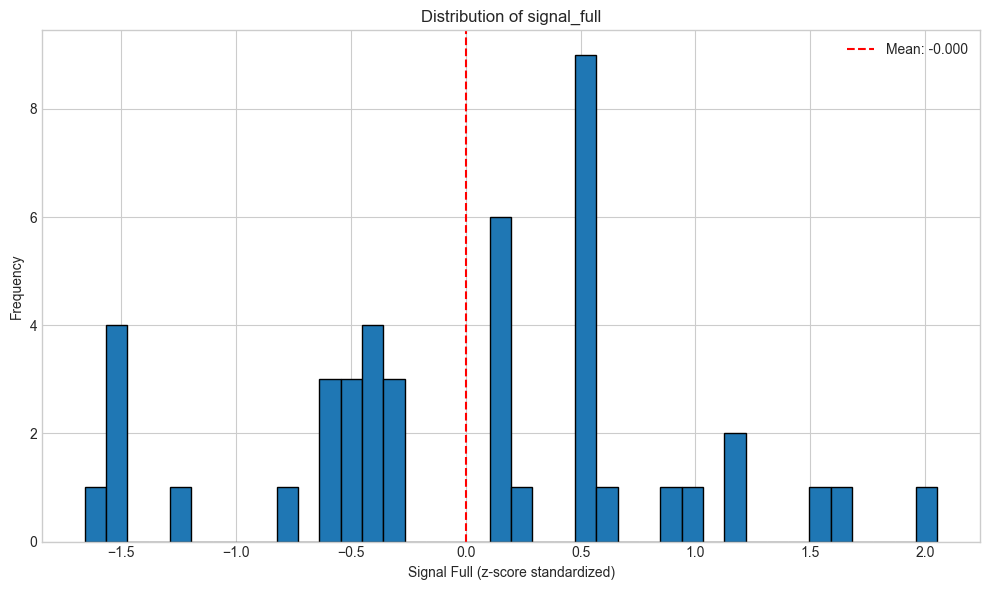

In [9]:
# Plot distribution of the full signal
fig, ax = plt.subplots(figsize=(10, 6))
df_signals['signal_full'].hist(bins=40, edgecolor='black', ax=ax)
ax.set_xlabel('Signal Full (z-score standardized)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of signal_full')
ax.axvline(df_signals['signal_full'].mean(), color='red', linestyle='--',
           label=f"Mean: {df_signals['signal_full'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/signal_full_distribution.png', dpi=150)
plt.show()

## Section 4.5 — Baseline Comparison

The baseline comparison tests whether adding uncertainty and event intensity
contributes incremental signal value beyond sentiment alone.

In [10]:
# Run baseline comparison
summary = evaluation.run_baseline_comparison(df_signals)
summary

,signal,mean_spread,spread_hit_rate,mean_ic,ic_hit_rate,n_days
0,signal_sentiment_only,0.02845,1.0,-0.045037,0.333333,1
1,signal_sentiment_minus_uncertainty,0.02845,1.0,-0.188893,0.250000,1
2,signal_full,0.02845,1.0,-0.110750,0.375000,1


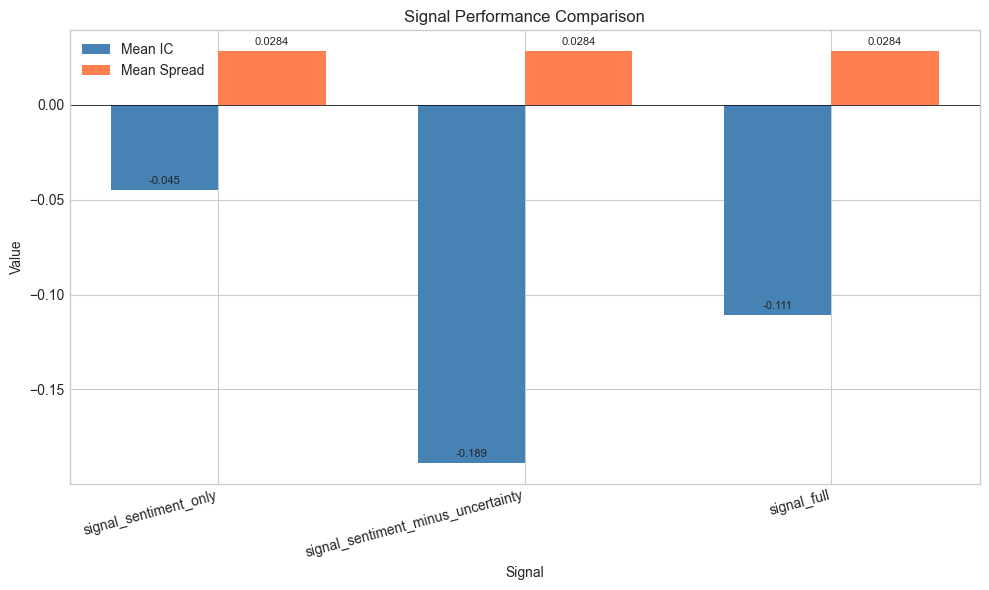

In [11]:
# Plot mean IC comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(summary))
width = 0.35

bars1 = ax.bar(x - width/2, summary['mean_ic'], width, label='Mean IC', color='steelblue')
bars2 = ax.bar(x + width/2, summary['mean_spread'], width, label='Mean Spread', color='coral')

ax.set_xlabel('Signal')
ax.set_ylabel('Value')
ax.set_title('Signal Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(summary['signal'], rotation=15, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/baseline_comparison.png', dpi=150)
plt.show()

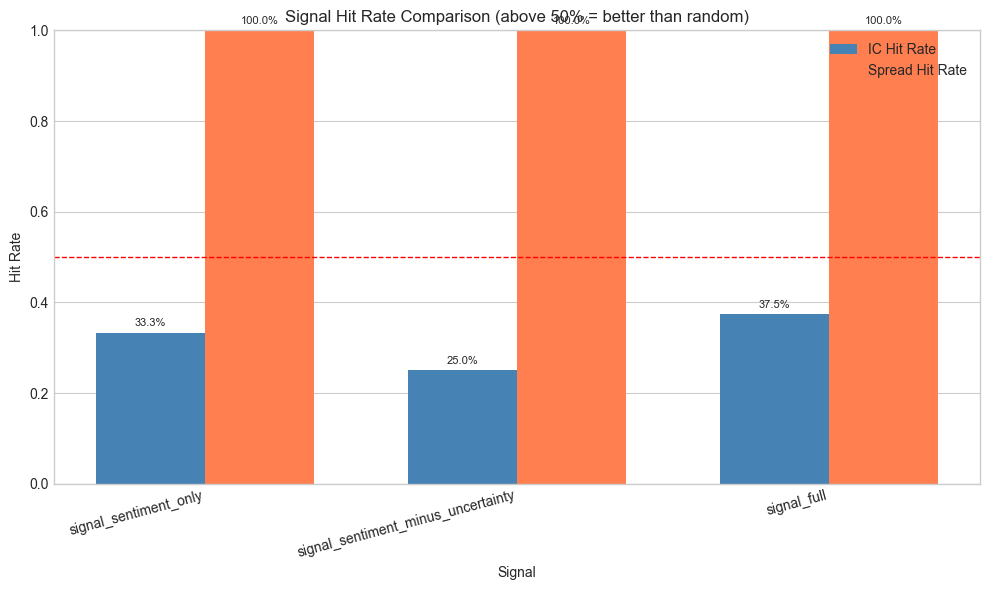

In [12]:
# Plot hit rates
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(summary))
width = 0.35

bars1 = ax.bar(x - width/2, summary['ic_hit_rate'], width, label='IC Hit Rate', color='steelblue')
bars2 = ax.bar(x + width/2, summary['spread_hit_rate'], width, label='Spread Hit Rate', color='coral')

ax.set_xlabel('Signal')
ax.set_ylabel('Hit Rate')
ax.set_title('Signal Hit Rate Comparison (above 50% = better than random)')
ax.set_xticks(x)
ax.set_xticklabels(summary['signal'], rotation=15, ha='right')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Random (50%)')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/hit_rate_comparison.png', dpi=150)
plt.show()

## Section 5 — Evaluation

All evaluation is cross-sectional (per trading date). We compute:
- **Grouped forward returns**: Mean return per quintile/tercile
- **Top-minus-Bottom spread**: Long top group, short bottom group
- **Spearman Rank IC**: Rank correlation between signal and forward return
- **Monthly stability**: Consistency of daily spreads over time

In [13]:
# Compute grouped returns for signal_full
grouped_returns = evaluation.compute_grouped_returns(df_signals, 'signal_full')
print(f"Grouped returns computed for {grouped_returns['date'].nunique()} dates")

# Compute overall mean by group
mean_by_group = grouped_returns.groupby('group')['mean_return'].mean()
print("\nMean return by group:")
print(mean_by_group)

Grouped returns computed for 1 dates

Mean return by group:
group
1   -0.052522
2   -0.024072
3   -0.032593
Name: mean_return, dtype: float64


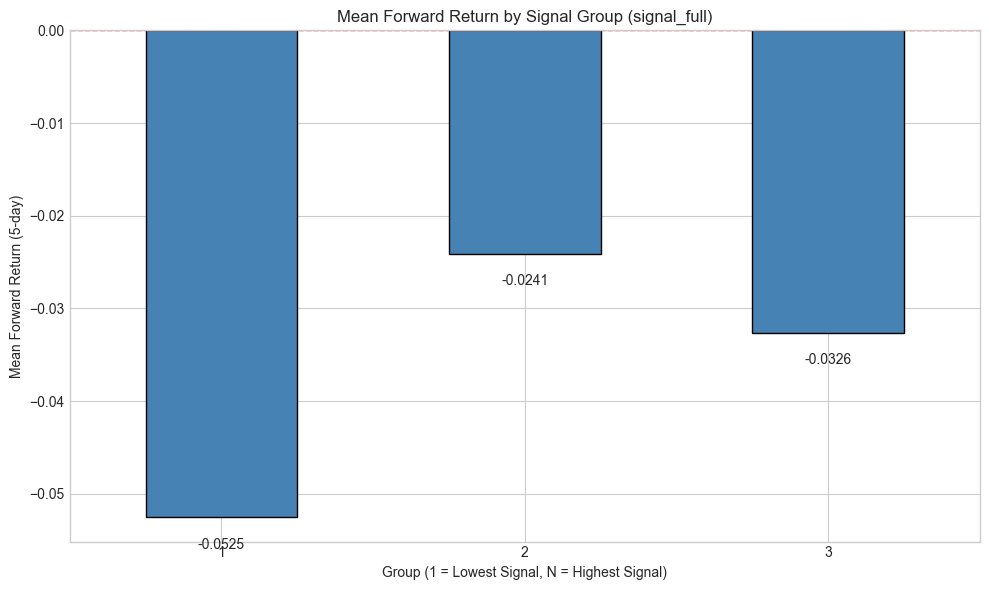

In [14]:
# Plot grouped returns
if len(mean_by_group) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    mean_by_group.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_xlabel('Group (1 = Lowest Signal, N = Highest Signal)')
    ax.set_ylabel('Mean Forward Return (5-day)')
    ax.set_title('Mean Forward Return by Signal Group (signal_full)')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    # Add value labels
    for i, v in enumerate(mean_by_group.values):
        ax.annotate(f'{v:.4f}',
                    xy=(i, v),
                    xytext=(0, 5 if v >= 0 else -15),
                    textcoords="offset points",
                    ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/grouped_returns.png', dpi=150)
    plt.show()
else:
    print("WARNING: No grouped returns available. Insufficient data to form groups.")
    print("This happens when each date has fewer than MIN_SAMPLE_DROP (9) observations.")
    print("Consider expanding the ticker universe or the lookback period.")

In [15]:
# Compute daily spread for signal_full
spread_series = evaluation.compute_daily_spread(df_signals, 'signal_full')
print(f"Daily spread computed for {len(spread_series)} dates")

if len(spread_series) > 0:
    print(f"Mean spread: {spread_series.mean():.4f}")
    print(f"Spread hit rate: {(spread_series > 0).mean():.1%}")
else:
    print("WARNING: No daily spreads available. Insufficient cross-sectional data per date.")

Daily spread computed for 1 dates
Mean spread: 0.0284
Spread hit rate: 100.0%


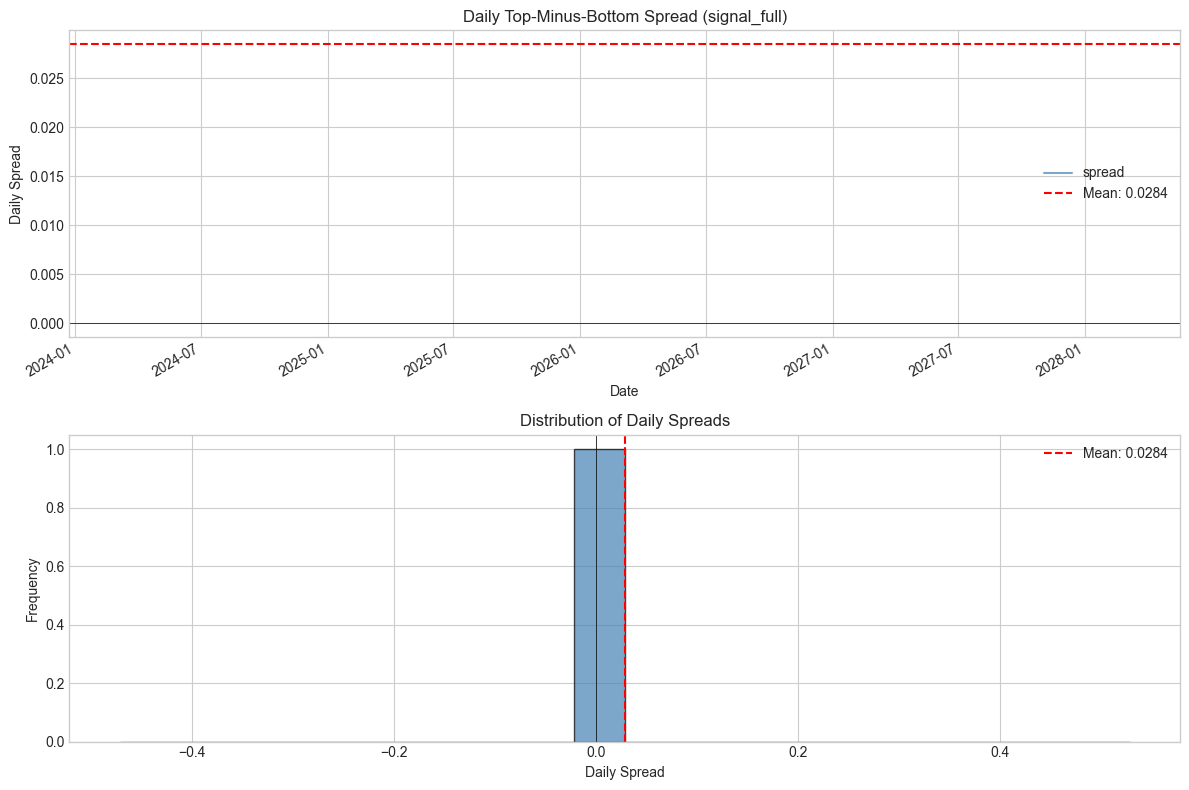

In [16]:
# Plot daily spread over time
if len(spread_series) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Time series
    ax1 = axes[0]
    spread_series.plot(ax=ax1, color='steelblue', alpha=0.7)
    ax1.axhline(y=spread_series.mean(), color='red', linestyle='--',
                label=f"Mean: {spread_series.mean():.4f}")
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Daily Spread')
    ax1.set_title('Daily Top-Minus-Bottom Spread (signal_full)')
    ax1.legend()

    # Histogram
    ax2 = axes[1]
    spread_series.hist(bins=20, edgecolor='black', ax=ax2, color='steelblue', alpha=0.7)
    ax2.axvline(spread_series.mean(), color='red', linestyle='--',
                label=f"Mean: {spread_series.mean():.4f}")
    ax2.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Daily Spread')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Daily Spreads')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/daily_spread.png', dpi=150)
    plt.show()
else:
    print("Skipping daily spread plot - no data available.")

In [17]:
# Compute daily IC
ic_series = evaluation.compute_daily_ic(df_signals, 'signal_full')
print(f"Daily IC computed for {len(ic_series)} dates")

if len(ic_series) > 0:
    print(f"Mean IC: {ic_series.mean():.4f}")
    print(f"IC hit rate: {(ic_series > 0).mean():.1%}")
    print(f"IC std: {ic_series.std():.4f}")
    print(f"IR (IC/Std): {ic_series.mean() / ic_series.std():.4f}")
else:
    print("WARNING: No daily ICs available. Insufficient cross-sectional data per date.")

Daily IC computed for 8 dates
Mean IC: -0.1107
IC hit rate: 37.5%
IC std: 0.4163
IR (IC/Std): -0.2660


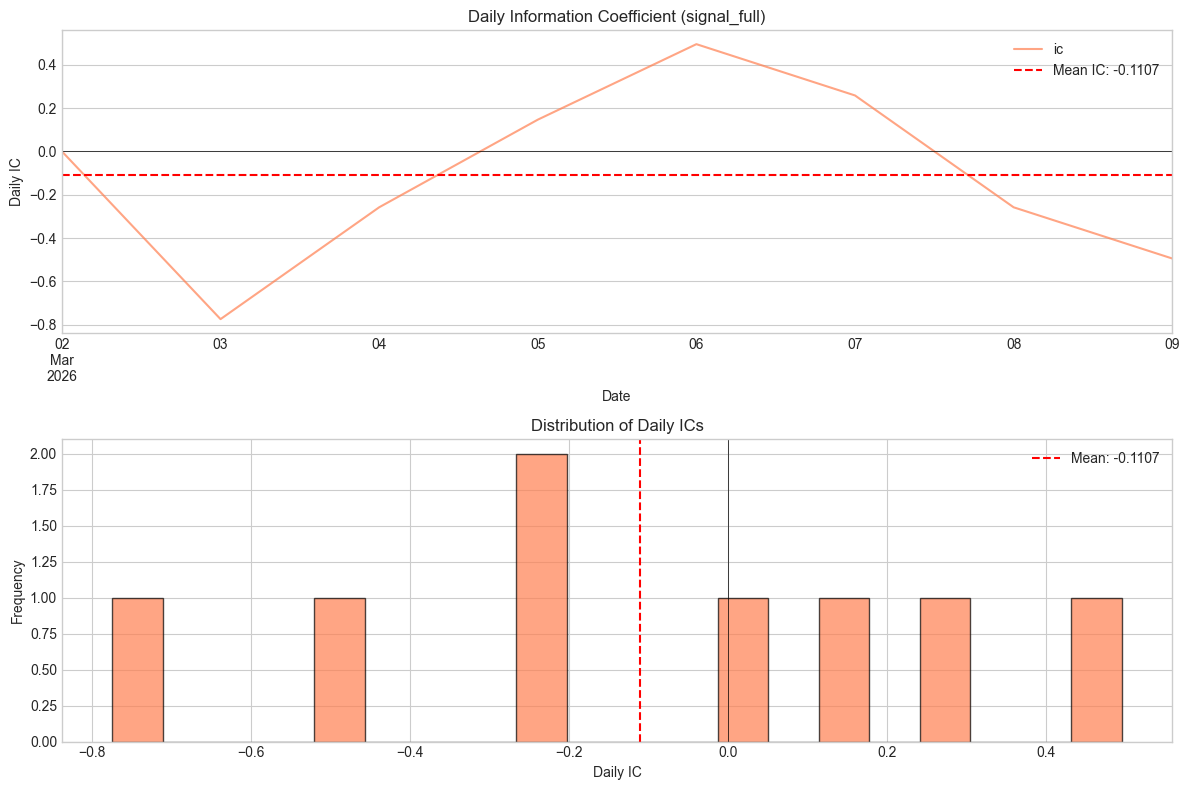

In [18]:
# Plot daily IC
if len(ic_series) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Time series
    ax1 = axes[0]
    ic_series.plot(ax=ax1, color='coral', alpha=0.7)
    ax1.axhline(y=ic_series.mean(), color='red', linestyle='--',
                label=f"Mean IC: {ic_series.mean():.4f}")
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Daily IC')
    ax1.set_title('Daily Information Coefficient (signal_full)')
    ax1.legend()

    # Histogram
    ax2 = axes[1]
    ic_series.hist(bins=20, edgecolor='black', ax=ax2, color='coral', alpha=0.7)
    ax2.axvline(ic_series.mean(), color='red', linestyle='--',
                label=f"Mean: {ic_series.mean():.4f}")
    ax2.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Daily IC')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Daily ICs')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/daily_ic.png', dpi=150)
    plt.show()
else:
    print("Skipping daily IC plot - no data available.")

In [19]:
# Compute monthly stability
monthly_spread = evaluation.compute_monthly_stability(spread_series)
print("Monthly mean spreads:")
print(monthly_spread if len(monthly_spread) > 0 else "No data available.")

Monthly mean spreads:
date
2026-03-31    0.02845
Freq: ME, Name: spread, dtype: float64


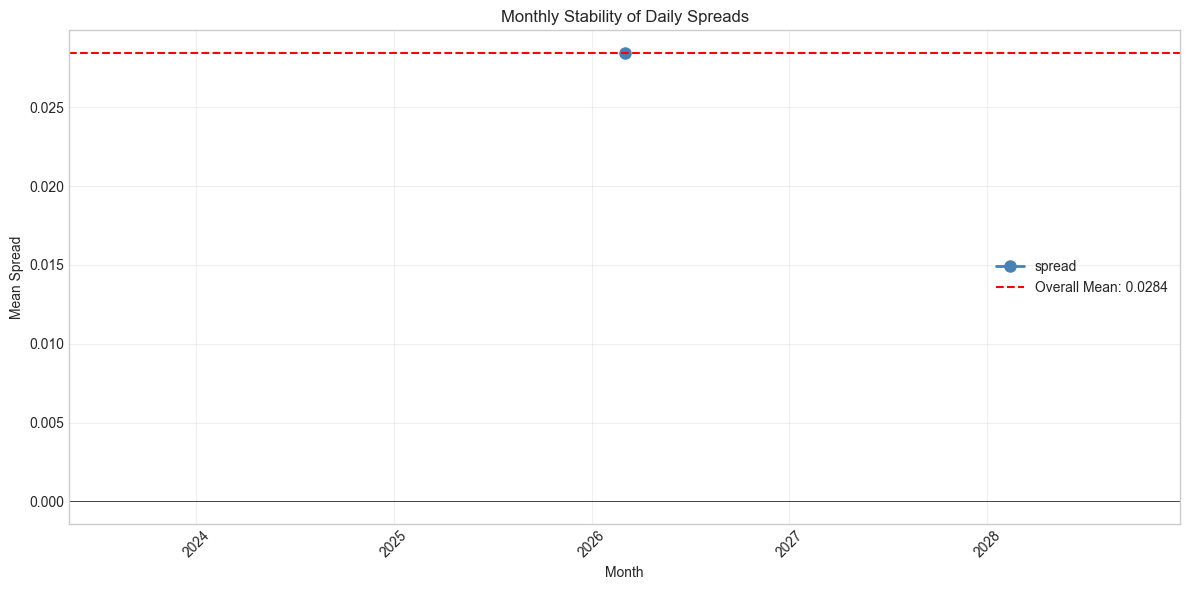

In [20]:
# Plot monthly stability
if len(monthly_spread) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    monthly_spread.plot(ax=ax, marker='o', color='steelblue', linewidth=2, markersize=8)
    ax.axhline(y=monthly_spread.mean(), color='red', linestyle='--',
               label=f"Overall Mean: {monthly_spread.mean():.4f}")
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Spread')
    ax.set_title('Monthly Stability of Daily Spreads')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/monthly_stability.png', dpi=150)
    plt.show()
else:
    print("Skipping monthly stability plot - no data available.")

## Section 6 — Conclusion

### Key Observations
[Leave placeholder text for user to fill in after running]

### Limitations
- Small sample and short horizon
- Survivorship bias in universe selection
- Community-grade data sources
- Prototype-level text labeling and signal design

### Research Note
In this case study, directional consistency and research process clarity
matter more than absolute performance magnitude.

### Next Steps
- Expand dataset and ticker universe
- Integrate Claude API for ai_label feature
- Add neutralization and transaction cost assumptions
- Validate on out-of-sample periods

## Section 7 — Export Results

Save summary tables and results to the results directory.

In [21]:
import os

# Ensure directories exist
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# Save summary tables
summary.to_csv(f'{TABLES_DIR}/baseline_comparison.csv', index=False)
print(f"Saved baseline comparison to {TABLES_DIR}/baseline_comparison.csv")

# Save grouped returns (if available)
if len(mean_by_group) > 0:
    mean_by_group.to_csv(f'{TABLES_DIR}/mean_returns_by_group.csv')
    print(f"Saved grouped returns to {TABLES_DIR}/mean_returns_by_group.csv")
else:
    print("No grouped returns to save.")

# Save daily metrics (if available)
if len(spread_series) > 0:
    metrics_df = pd.DataFrame({
        'date': spread_series.index,
        'spread': spread_series.values,
    })
    metrics_df.to_csv(f'{TABLES_DIR}/daily_spread.csv', index=False)
    print(f"Saved daily spread to {TABLES_DIR}/daily_spread.csv")
else:
    print("No daily spread data to save.")

if len(ic_series) > 0:
    ic_df = pd.DataFrame({
        'date': ic_series.index,
        'ic': ic_series.values,
    })
    ic_df.to_csv(f'{TABLES_DIR}/daily_ic.csv', index=False)
    print(f"Saved daily IC to {TABLES_DIR}/daily_ic.csv")
else:
    print("No daily IC data to save.")

# Save monthly stability (if available)
if len(monthly_spread) > 0:
    monthly_spread.to_csv(f'{TABLES_DIR}/monthly_stability.csv')
    print(f"Saved monthly stability to {TABLES_DIR}/monthly_stability.csv")
else:
    print("No monthly stability data to save.")

print("\nAll results exported successfully!")

Saved baseline comparison to /Users/yizuo/news-to-signal/news-to-signal-case-study/results/tables/baseline_comparison.csv
Saved grouped returns to /Users/yizuo/news-to-signal/news-to-signal-case-study/results/tables/mean_returns_by_group.csv
Saved daily spread to /Users/yizuo/news-to-signal/news-to-signal-case-study/results/tables/daily_spread.csv
Saved daily IC to /Users/yizuo/news-to-signal/news-to-signal-case-study/results/tables/daily_ic.csv
Saved monthly stability to /Users/yizuo/news-to-signal/news-to-signal-case-study/results/tables/monthly_stability.csv

All results exported successfully!
